In [1]:
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = Path("/home/jonas/Datasets/TikZ/train-big")
MANIFEST_PATH = DATASET_PATH / "hardest_manifest.csv"

df = pd.read_csv(MANIFEST_PATH)

df.head()

,code_path,image_path,vlm_description_path,reference_image,reference_code,input_image_format_for_vlm,vlm_description,sft_loss,sft_answer_tokens
0,/data/references/geotikz_bridge_base_01923710.txt,/data/images/geotikz_bridge_base_01923710.png,/data/vlm_descriptions/geotikz_bridge_base_019...,NaN,NaN,NaN,NaN,7.62500,106
1,/data/references/our_dataset_00001499.txt,/data/images/our_dataset_00001499.png,/data/vlm_descriptions/our_dataset_00001499.txt,NaN,NaN,NaN,NaN,7.25000,98
2,/data/references/geotikz_bridge_base_00197722.txt,/data/images/geotikz_bridge_base_00197722.png,/data/vlm_descriptions/geotikz_bridge_base_001...,NaN,NaN,NaN,NaN,7.09375,626
3,/data/references/geotikz_bridge_base_00241830.txt,/data/images/geotikz_bridge_base_00241830.png,/data/vlm_descriptions/geotikz_bridge_base_002...,NaN,NaN,NaN,NaN,6.78125,352
4,/data/references/our_dataset_00083623.txt,/data/images/our_dataset_00083623.png,/data/vlm_descriptions/our_dataset_00083623.txt,NaN,NaN,NaN,NaN,6.53125,142


In [2]:
df_sorted = df.sort_values("sft_loss", ascending=False).reset_index(drop=True)
df_sorted[["image_path", "sft_loss", "sft_answer_tokens"]].head(20)

,image_path,sft_loss,sft_answer_tokens
0,/data/images/geotikz_bridge_base_01923710.png,7.62500,106
1,/data/images/our_dataset_00001499.png,7.25000,98
2,/data/images/geotikz_bridge_base_00197722.png,7.09375,626
3,/data/images/geotikz_bridge_base_00241830.png,6.78125,352
4,/data/images/our_dataset_00083623.png,6.53125,142
5,/data/images/our_dataset_00058018.png,6.46875,98
6,/data/images/geotikz_bridge_base_00356250.png,6.43750,208
7,/data/images/datikz_v4_00264167.png,6.34375,414
8,/data/images/geotikz_bridge_base_00066071.png,6.31250,1320
9,/data/images/geotikz_bridge_base_01679943.png,6.28125,126


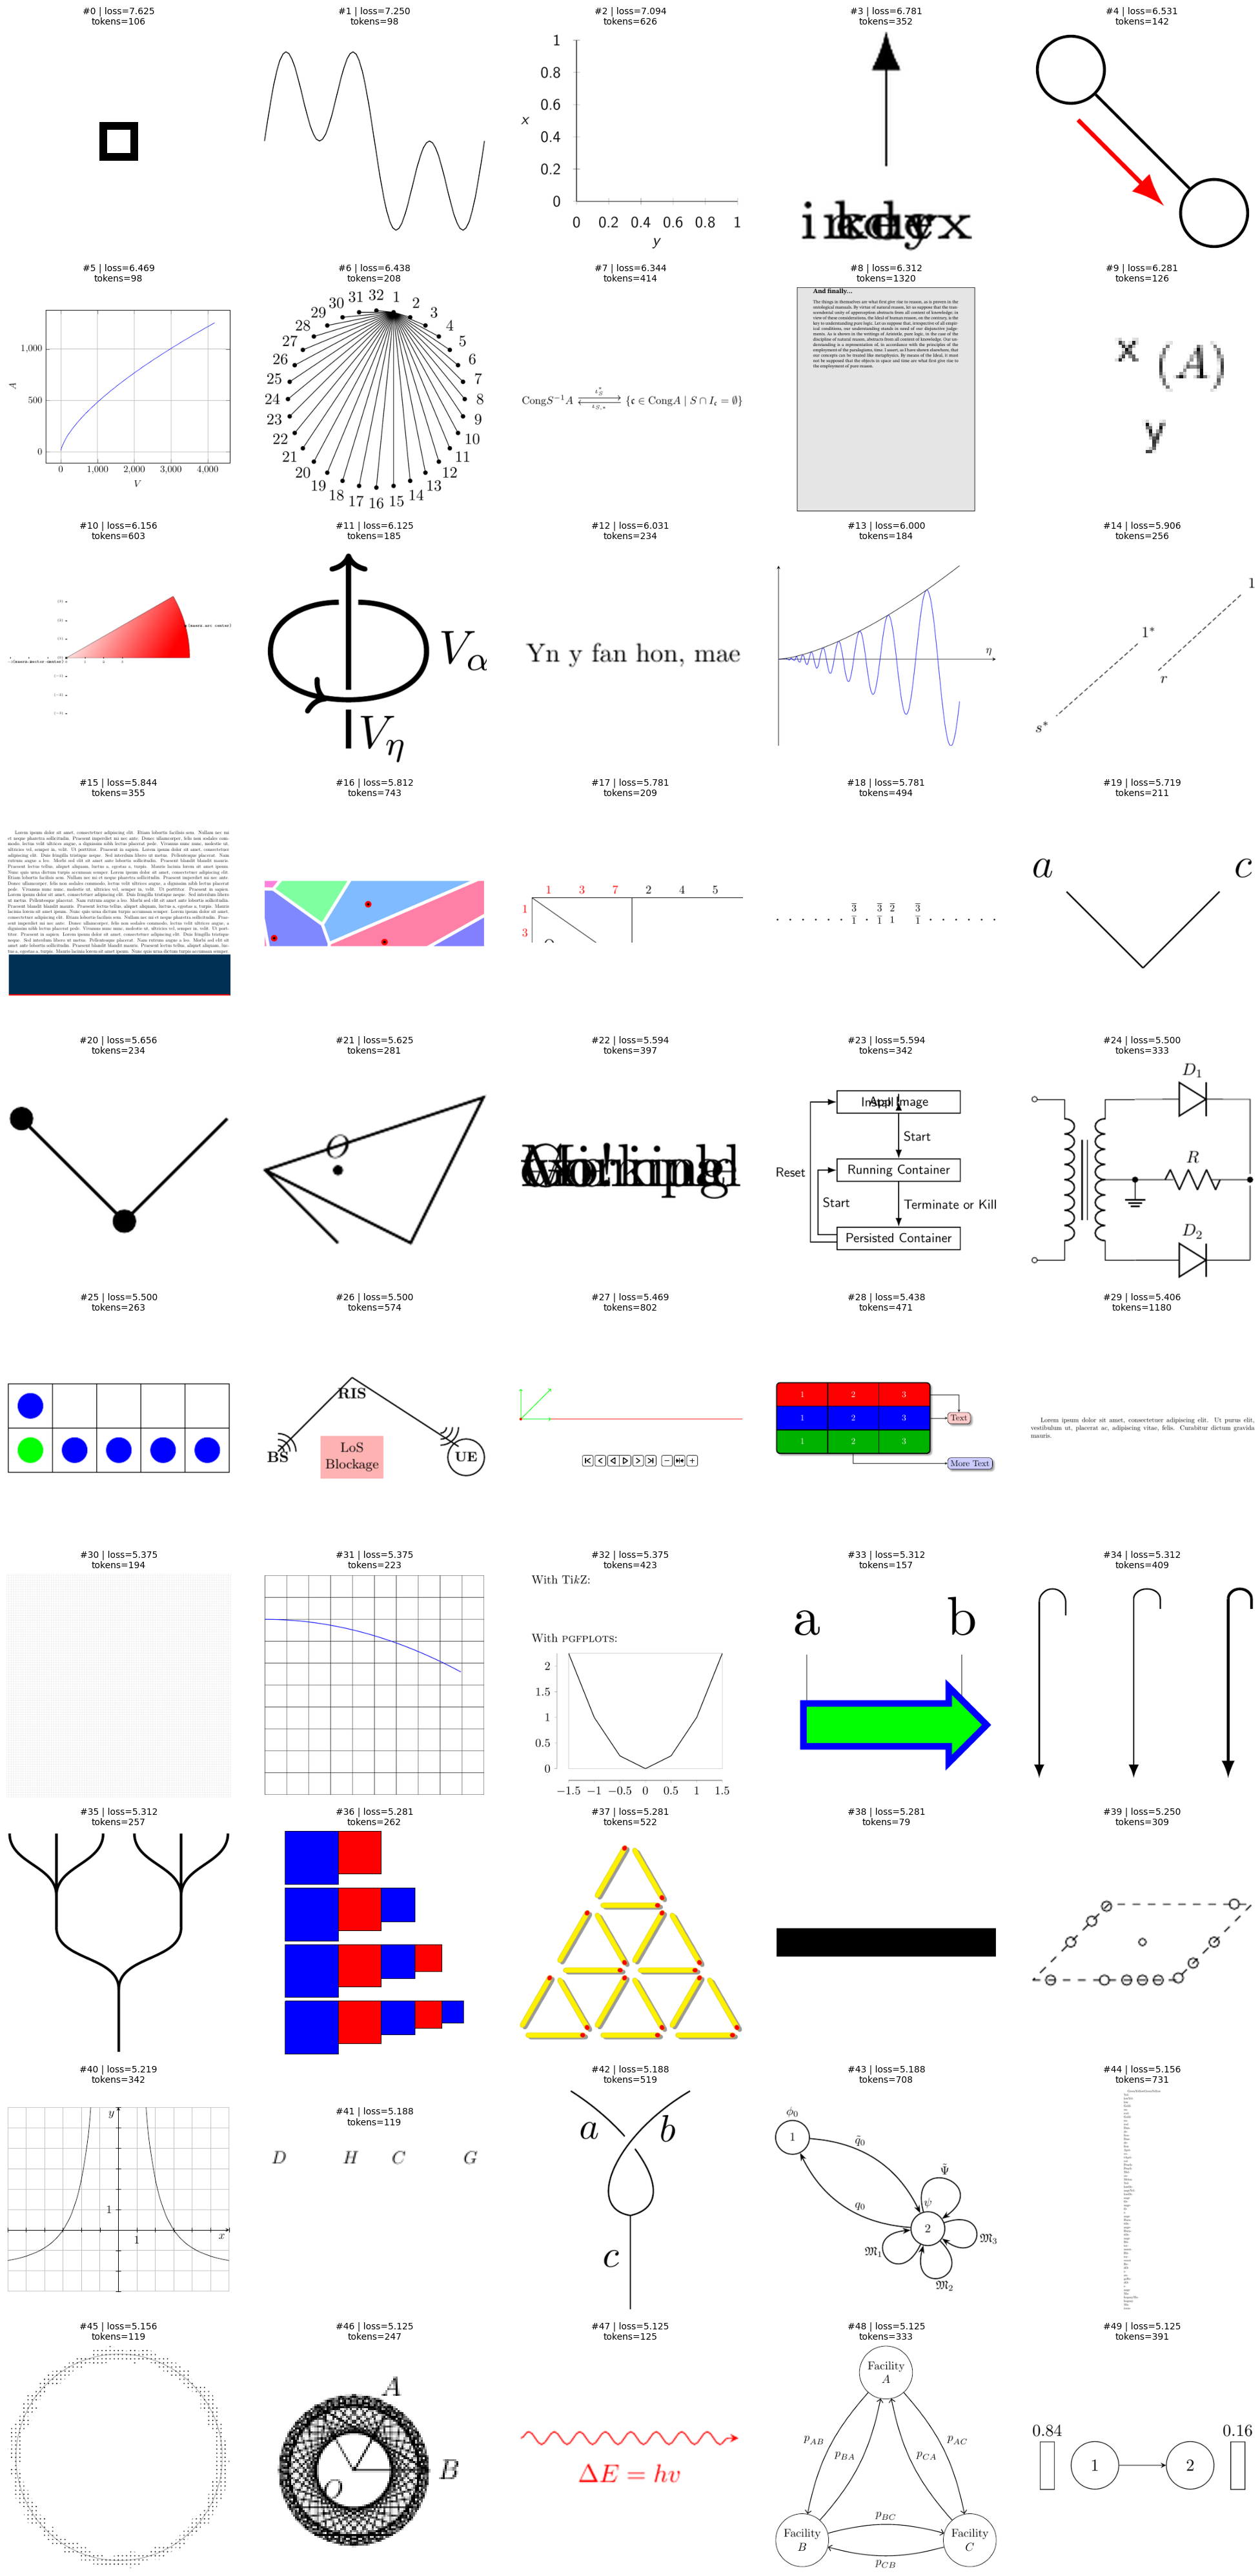

In [30]:
def resolve(root, p):
    p = p.replace("/data", str(DATASET_PATH))
    p = Path(str(p))
    return p if p.is_absolute() else root / p


def show_samples(df, n=12, cols=4, root=DATASET_PATH):
    rows = min(n, len(df))
    plot_rows = (rows + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * plot_rows))

    for i in range(rows):
        row = df.iloc[i]
        img_path = resolve(root, row["image_path"])
        img = Image.open(img_path).convert("RGB")

        ax = plt.subplot(plot_rows, cols, i + 1)
        ax.imshow(img)
        ax.axis("off")

        loss = row["sft_loss"]
        tokens = row.get("sft_answer_tokens", None)

        title = f"#{i} | loss={loss:.3f}"
        if tokens is not None:
            title += f"\ntokens={int(tokens)}"

        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.show()


show_samples(df_sorted, n=50, cols=5)

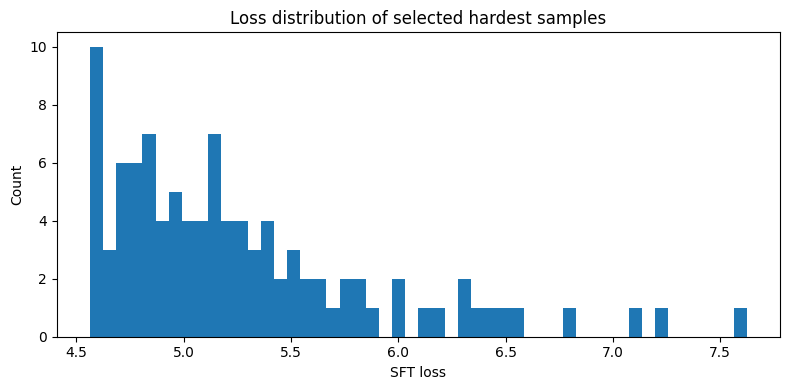

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(df["sft_loss"], bins=50)
plt.xlabel("SFT loss")
plt.ylabel("Count")
plt.title("Loss distribution of selected hardest samples")
plt.tight_layout()
plt.show()

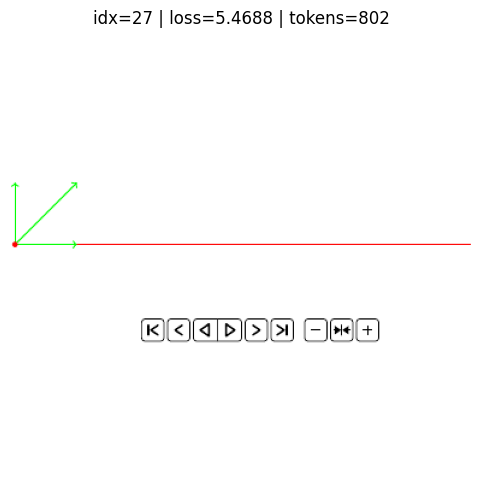

\documentclass[11pt]{article}
\usepackage{tikz}
\usetikzlibrary{decorations.pathreplacing}
\usepackage{animate}
\usepackage{ifthen}
%\setbeamertemplate{navigation symbols}{}
\begin{document}
%\begin{frame}
\def\rg{2}
\begin{animateinline}[poster=first,controls]{8}%
\multiframe{37}{rt=0+.1,icount=1+1,rvo=5+0.0,rtheta=45+.0}
{% rt=time, rvo=initial v, g=2, rtheta=inital angle
\begin{tikzpicture}[scale=.75]
\clip (-1,-2) rectangle (15,10); % For body projected upward with angle rtheta=45
%\clip (-1,-8) rectangle (15,1);   % For body projected horizontally, rtheta=0
\draw[red] (0,0)--(13,0);         % ground horizontal line
\coordinate (A\icount) at ({\rvo*cos(\rtheta)*(\rt)},{\rvo*sin(\rtheta)*(\rt)-0.5*\rg*(\rt)*(\rt)}) {};              % (x,y) position,
\path (A\icount) -- + ({0.5*\rvo*cos(\rtheta)},{0.5*(\rvo*sin(\rtheta)-\rg*(\rt))}) coordinate (B\icount){};  % (V_x,V_y) position , scaled by 0.5
\draw[thick,green,->] (A\icount.center) -- (B\icount-|A\icount);
\draw[thick,green,->] (A\

In [29]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

idx = 27

row = df_sorted.iloc[idx]

img_path = str(row["image_path"])
img_path = img_path.replace("/data", str(DATASET_PATH))
img_path = Path(img_path)

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"idx={idx} | loss={row['sft_loss']:.4f} | tokens={int(row['sft_answer_tokens'])}")
plt.show()

ref_code_path = str(row["code_path"])
ref_code_path = ref_code_path.replace("/data", str(DATASET_PATH))

with open(ref_code_path, encoding="utf-8") as f:
    ref_code = f.read()

print(ref_code)